In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.optimize import fsolve
import importlib
import fit_thermal_rc_model
import sys
import datetime

sys.path.append(r"D:\Jupyter\CrystaLiZe\CrystaLiZe-SlowControlsData-main")
from crystalize_slowcontrolsdata.boxDownload import readBoxCSV

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")
mpl.rcdefaults()

importlib.reload(fit_thermal_rc_model)
from fit_thermal_rc_model import (
    plot_fit,
    plot_validation,
    save_results,
    save_validation_results,
    validate_experiment_arrays,
    print_validation_summary, 
)

In [2]:
a = 8.17430058
b = 22.45378994
def coldhead_power_with_efficiency(CH_temp, eff):
    # corrected coldhead power in cases where coldhead is < 100% efficient
    # ideally, 0 < eff <= 1
    power = a * np.sqrt(CH_temp - b)
    power = eff * power
    return power

In [3]:
# 7d
start_time = datetime.datetime(2026, 3, 7, 21, 30, 0)
end_time = datetime.datetime(2026, 3, 9, 6, 0, 0)

In [4]:
df = readBoxCSV(
    key="Lakeshore",
    timeCol="Time",
    start_time=start_time,
    end_time=end_time,
    download=True,
    return_df=True
)
# df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H_%M_%S", errors="coerce")
print(df.shape)

2026-03-07 13_19_57.csv: 47.0MB [00:01, 44.9MB/s]


(91475, 26)


In [78]:
start_time = '2026-03-08 2:40:00'
end_time = '2026-03-09 06:00:00'
df_selected = df[df['Time'].between(start_time, end_time)]
time = df_selected['Time']
time_relative = df_selected['Elapsed Time(s)'].to_numpy()
bot_flange = df_selected['RTDD3 Temperature(K)'].to_numpy()
top_flange = df_selected['RTDD4 Temperature(K)'].to_numpy()
Heater1 = df_selected['Heater1 Output(W)'].to_numpy()
Heater2 = df_selected['Heater2 Output(W)'].to_numpy()
CH_temp = df_selected['RTDD5 Temperature(K)'].to_numpy()
CH_power = coldhead_power_with_efficiency(CH_temp, eff=1)
CH_power = np.asarray(CH_power, dtype=float)

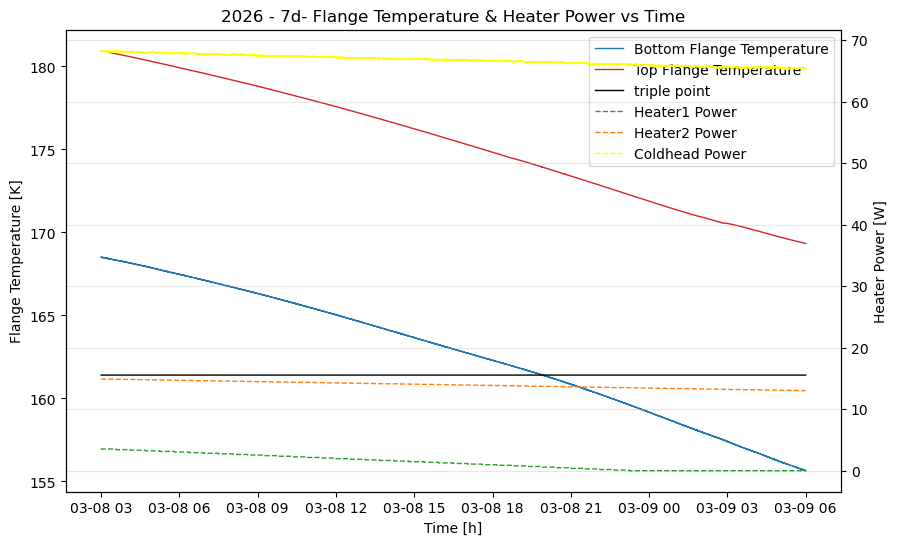

In [7]:
HeaterCH = coldhead_power_with_efficiency(CH_temp, 1)
Heateri0 = HeaterCH-Heater1-Heater2
T_triple = 161.406
triple = [T_triple] * len(time)

fig, ax1 = plt.subplots(figsize=(10, 6))

line11 = ax1.plot(time, bot_flange, color='tab:blue', linewidth=1, label='Bottom Flange Temperature')
line12 = ax1.plot(time, top_flange, color='tab:red', linewidth=1, label='Top Flange Temperature')
# line13 = ax1.plot(time, CH_temp, color='purple', linewidth=0.5, label='coldhead Temperature')
# line13 = ax1.plot(time, top_flange-bot_flange, color='purple', linewidth=0.5, label='Temperature difference')
line14 = ax1.plot(time, triple, color='black', linewidth=1, label='triple point')

ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Flange Temperature [K]')
# ax1.tick_params(axis='y', labelcolor='tab:blue')  
ax2 = ax1.twinx()

line21 = ax2.plot(time, Heater1, color='tab:green', linestyle='--', linewidth=1, label='Heater1 Power')
line22 = ax2.plot(time, Heater2, color='tab:orange', linestyle='--', linewidth=1, label='Heater2 Power')
line23 = ax2.plot(time, HeaterCH, color='yellow', linestyle='--', linewidth=1, label='Coldhead Power')
# line24 = ax2.plot(time, Heateri0, color='black', linestyle='--', linewidth=0.5, label='i0 Power')

ax2.set_ylabel('Heater Power [W]')
# ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line11 + line12 + line14 + line21 + line22 + line23 # + line24
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

title_string = "2026 - 7d- Flange Temperature & Heater Power vs Time"
plt.title(title_string)

plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

In [13]:
from fit_thermal_rc_model import (
    ThermalParameters,
    fit_experiment_arrays,
    print_fit_summary,
    plot_fit,
    save_results,
)

initial_guess = ThermalParameters(
    R_tb=1/2.06,       # K/W
    R_tc=1/0.32768, # K/W
    R_bc=1/0.75838, # K/W
    C_t=5.0e2,      # J/K
    C_b=5.0e2,      # J/K
    C_CH=0,     # J/K
    # i0=50,
)

result, actual_dt = fit_experiment_arrays(
    time_relative=time,
    bot_flange=bot_flange,
    top_flange=top_flange,
    CH_temp=CH_temp,
    CH_power=CH_power,
    Heater1=Heater1,
    Heater2=Heater2,

    fit_dt_s=5.0,
    max_gap_s=60.0,
    initial=initial_guess,

    temperature_sigma_k=(0.02, 0.02, 0.5),

    max_nfev=300,
)

print(f"Actual fitting time step: {actual_dt:.3f} s")
print_fit_summary(result)

`ftol` termination condition is satisfied.
Function evaluations 22, initial cost 2.2007e+07, final cost 7.7560e+05, first-order optimality 4.92e+01.
Actual fitting time step: 5.000 s
Fitted parameters
  R_tb  = 0.24804689 +/- 0.0263 K/W
  R_tc  = 3.0517578 K/W (fixed)
  R_bc  = 1.3186002 K/W (fixed)
  C_t   = 100000 +/- 4.67e+04 J/K
  C_b   = 46534.578 +/- 4.72e+04 J/K
  C_CH  = 0 J/K (fixed)
  i0(T_top) = -0.3348 * T_top + 110.7 W (T_top in K)
Fit targets         = T_t, T_b; measured T_CH is the boundary input
success             = True
reduced chi-square  = 766.854
optimizer message   = `ftol` termination condition is satisfied.


In [22]:
index = np.argmax(bot_flange <= T_triple)
print(bot_flange[index])
Tc_0 = CH_temp[index]
Tb_0 = bot_flange[index]
Tt_0 = top_flange[index]
H1_0 = Heater1[index]
H2_0 = Heater2[index]

161.405


In [47]:
G_tb = 1 / result.parameters.R_tb # W/K
G_bc = 1 / result.parameters.R_bc
G_tc = 1 / result.parameters.R_tc
print(result.parameters.R_tb)
beta = 0.38 / 3600 # K/s
t0 = (Tc_0-b) * CH_power[index] / (3*beta*(G_bc+G_tc)) - Tc_0 / beta
print(t0/3600)
def time_Tc(Tc):
    temp = Tc - coldhead_power_with_efficiency(Tc, 1) * (Tc-b) / (3*(G_bc+G_tc))
    t = temp / beta + t0
    return t

0.24804688723899973
3315.034790572155


Equation: time = -77.85*T_CH + 6893.18


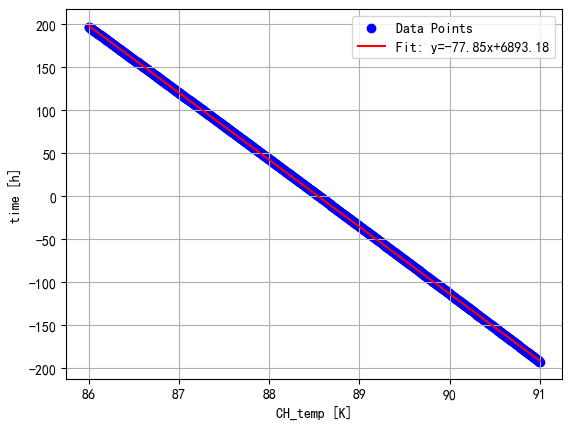

In [65]:
from numpy.polynomial import Polynomial
# from scipy.interpolate import make_interp_spline
Tc_samples = np.linspace(86, 91, 1001)
time_samples = time_Tc(Tc_samples) / 3600
# inv_spline = make_interp_spline(Tc_samples, time_samples, k=3)
# print(inv_spline)
fit = Polynomial.fit(Tc_samples, time_samples, deg=1).convert()
intercept, slope = fit.coef
print(f"Equation: time = {slope:.2f}*T_CH + {intercept:.2f}")
time_pred = fit(Tc_samples)

plt.figure()
plt.scatter(Tc_samples, time_samples, color="blue", label="Data Points")
plt.plot(Tc_samples, time_pred, color="red", label=f"Fit: y={slope:.2f}x+{intercept:.2f}")
plt.xlabel("CH_temp [K]")
plt.ylabel("time [h]")
plt.grid(True)
plt.legend()
plt.show()

In [68]:
beta = 0.38 #K/h
dot_Tc = 1 / slope
dot_Ic = (-beta-dot_Tc) * (G_bc+G_tc)
dot_I1 = (-beta-dot_Tc) * G_bc
dot_I2 = (-beta-dot_Tc) * G_tc - 0.3348 * beta

In [91]:
time_cool = time[index:]
hours = [(t_cool - time[index]).total_seconds() for t_cool in time_cool]
hours = np.asarray(hours)
hours = hours / 3600
hours = hours - hours[0]
Tb = Tb_0 - beta * hours
Tt = Tt_0 - beta * hours
Tc = Tc_0 + dot_Tc * hours
I1 = H1_0 + dot_I1 * hours
I2 = H2_0 + dot_I2 * hours
Ic = CH_power[index] + dot_Tc * hours

In [92]:
print(hours)

[0.00000000e+00 2.77777778e-04 5.55555556e-04 ... 1.00894444e+01
 1.00897222e+01 1.00900000e+01]


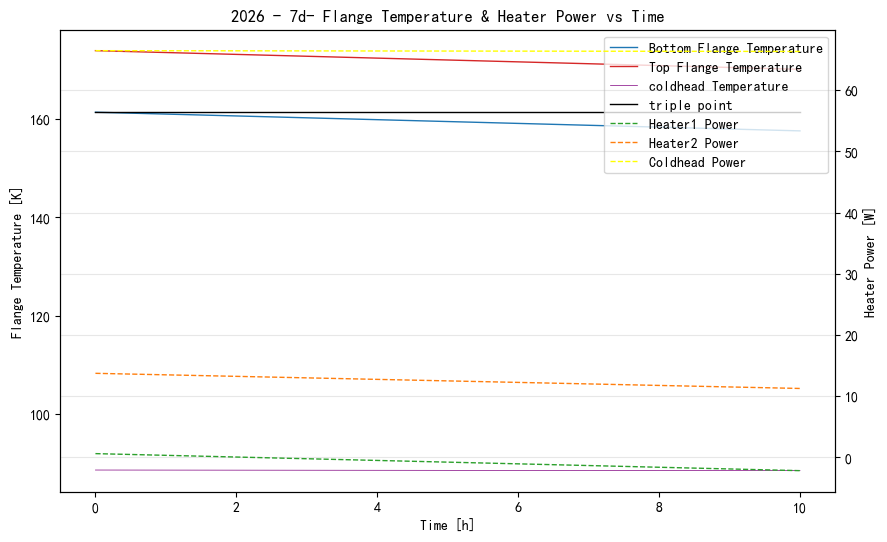

In [74]:
fig, ax1 = plt.subplots(figsize=(10, 6))

line11 = ax1.plot(hours, Tb, color='tab:blue', linewidth=1, label='Bottom Flange Temperature')
line12 = ax1.plot(hours, Tt, color='tab:red', linewidth=1, label='Top Flange Temperature')
line13 = ax1.plot(hours, Tc, color='purple', linewidth=0.5, label='coldhead Temperature')
# line13 = ax1.plot(time, top_flange-bot_flange, color='purple', linewidth=0.5, label='Temperature difference')
line14 = ax1.plot(hours, [T_triple] * len(hours), color='black', linewidth=1, label='triple point')

ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Flange Temperature [K]')
# ax1.tick_params(axis='y', labelcolor='tab:blue')  
ax2 = ax1.twinx()

line21 = ax2.plot(hours, I1, color='tab:green', linestyle='--', linewidth=1, label='Heater1 Power')
line22 = ax2.plot(hours, I2, color='tab:orange', linestyle='--', linewidth=1, label='Heater2 Power')
line23 = ax2.plot(hours, Ic, color='yellow', linestyle='--', linewidth=1, label='Coldhead Power')
# line24 = ax2.plot(time, Heateri0, color='black', linestyle='--', linewidth=0.5, label='i0 Power')

ax2.set_ylabel('Heater Power [W]')
# ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line11 + line12 + line13 + line14 + line21 + line22 + line23 # + line24
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

title_string = "2026 - 7d- Flange Temperature & Heater Power vs Time"
plt.title(title_string)

plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

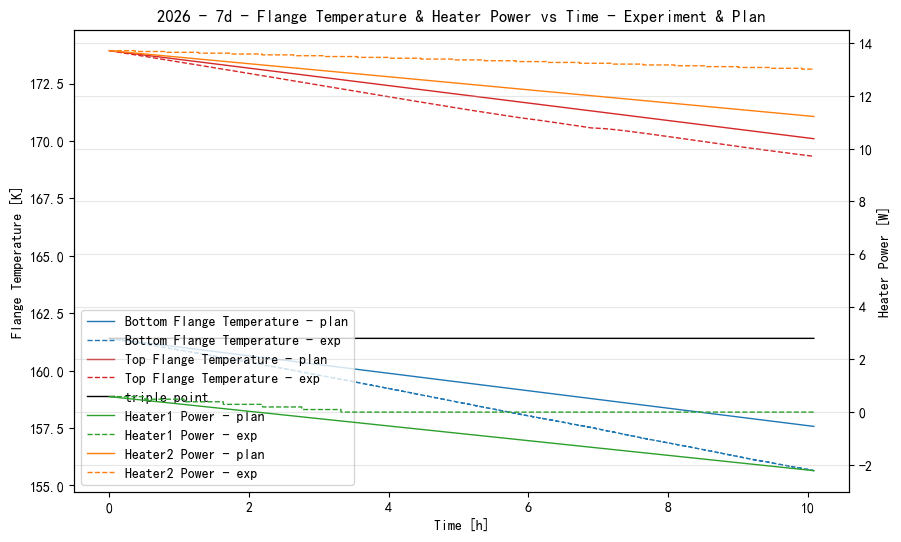

In [94]:
fig, ax1 = plt.subplots(figsize=(10, 6))

line11 = ax1.plot(hours, Tb, color='tab:blue', linewidth=1, label='Bottom Flange Temperature - plan')
line12 = ax1.plot(hours, bot_flange[index:], color='tab:blue', linestyle='--', linewidth=1, label='Bottom Flange Temperature - exp')
line13 = ax1.plot(hours, Tt, color='tab:red', linewidth=1, label='Top Flange Temperature - plan')
line14 = ax1.plot(hours, top_flange[index:], color='tab:red', linestyle='--', linewidth=1, label='Top Flange Temperature - exp')
line15 = ax1.plot(hours, [T_triple] * len(hours), color='black', linewidth=1, label='triple point')

ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Flange Temperature [K]')
# ax1.tick_params(axis='y', labelcolor='tab:blue')  
ax2 = ax1.twinx()

line21 = ax2.plot(hours, I1, color='tab:green', linewidth=1, label='Heater1 Power - plan')
line22 = ax2.plot(hours, Heater1[index:], color='tab:green', linestyle='--', linewidth=1, label='Heater1 Power - exp')
line23 = ax2.plot(hours, I2, color='tab:orange', linewidth=1, label='Heater2 Power - plan')
line24 = ax2.plot(hours, Heater2[index:], color='tab:orange', linestyle='--', linewidth=1, label='Heater2 Power - exp')

ax2.set_ylabel('Heater Power [W]')
# ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line11 + line12 + line13 + line14 + line15 + line21 + line22 + line23 + line24
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')

title_string = "2026 - 7d - Flange Temperature & Heater Power vs Time - Experiment & Plan"
plt.title(title_string)

plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()